# Example: Surface brightness profile extraction and fitting

This thread shows how to read data, extract surface brightness profiles, fit data and extract density profiles with _PyProffit_. 

## Reading data ##

We start by loading the packages:

In [1]:
import numpy as np
import pyproffit
import matplotlib.pyplot as plt
import os

# Change this to the proper directory containing your run
os.chdir('../../validation/') 

<class 'ModuleNotFoundError'>: No module named 'pyproffit'

Now we load the data inside a [Data](https://pyproffit.readthedocs.io/en/latest/pyproffit.html#pyproffit.data.Data) object in PyProffit structure:

In [3]:
dat=pyproffit.Data(imglink='b_37.fits.gz',explink='expose_mask_37.fits.gz',
                   bkglink='back_37.fits.gz')

,the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


1. Here _imglink=_'b_37.fits.gz'_ is the link to the image file (count map) to be loaded.
2. _explink=_'expose_mask_37.fits.gz' is the exposure map.   
3. _bkglink=_'back_37.fits.gz' is the background map.

The images are then loaded into the [Data](https://pyproffit.readthedocs.io/en/latest/pyproffit.html#pyproffit.data.Data) structure and can be easily accessed as below:

<ipython-input-4-00e9545509bd>:3: RuntimeWarning: divide by zero encountered in log10
,  plt.imshow(np.log10(dat.img),aspect='auto')


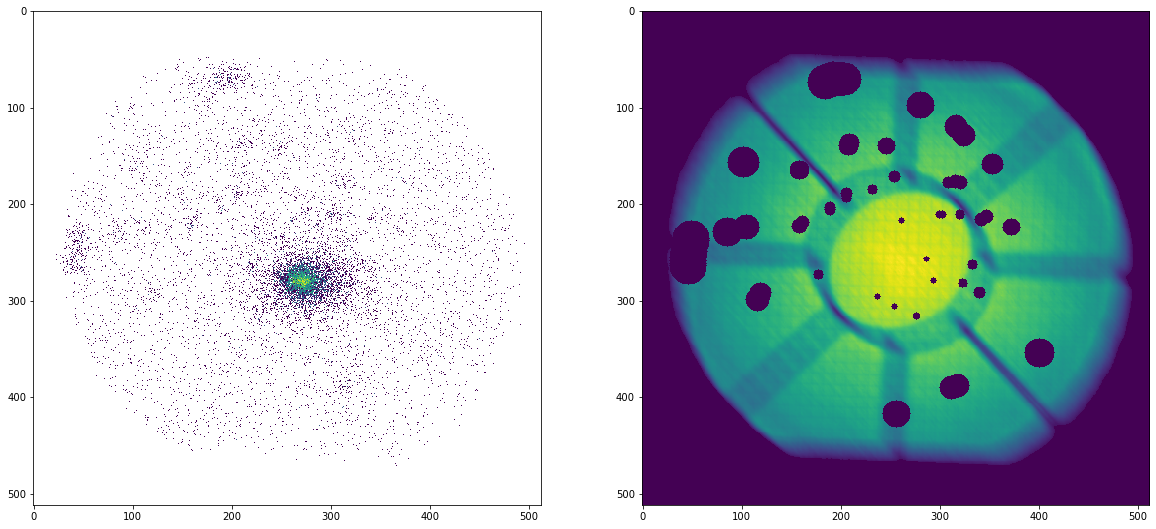

In [4]:
fig = plt.figure(figsize=(20,20))
s1=plt.subplot(221)
plt.imshow(np.log10(dat.img),aspect='auto')
s2=plt.subplot(222)
plt.imshow(dat.exposure,aspect='auto')

All the areas with zero exposure will be automatically excluded. We can ignore additional regions using the [region](https://pyproffit.readthedocs.io/en/latest/pyproffit.html#pyproffit.data.Data.region) method of the [Data](https://pyproffit.readthedocs.io/en/latest/pyproffit.html#pyproffit.data.Data) class, which loads a DS9 region file (in image or FK5 format):

In [5]:
dat.region('test_region.reg')

Excluded 2 sources


The [Data](https://pyproffit.readthedocs.io/en/latest/pyproffit.html#pyproffit.data.Data) structure also contains the [dmfilth](https://pyproffit.readthedocs.io/en/latest/pyproffit.html#pyproffit.data.Data.dmfilth) method, which can be used to fill the masked areas. The method computes a 2D spline interpolation in between the gaps and generates a Poisson realization of the spline interpolated data, such that the filled holes have similar statistical properties to their surroundings

In [7]:
dat.dmfilth()

Applying high-pass filter
,Interpolating in the masked regions
,Filling holes


## Profile extraction ##

Now we define a [Profile](https://pyproffit.readthedocs.io/en/latest/pyproffit.html#pyproffit.profextract.Profile) object in the following way:


In [9]:
prof=pyproffit.Profile(dat,center_choice='centroid',maxrad=45.,binsize=20.,centroid_region=30.)

Computing centroid and ellipse parameters using principal component analysis
,No approximate center provided, will search for the centroid within a radius of 30 arcmin from the center of the image
,Denoising image...
,Running PCA...
,Centroid position: 272.6425582785415 277.47130902570234
,Corresponding FK5 coordinates:  55.71693918958471 -53.642873306648674
,Ellipse axis ratio and position angle: 1.112280720144629 -144.82405288826155


<h3>Profile class options</h3>

The class [Profile](https://pyproffit.readthedocs.io/en/latest/pyproffit.html#pyproffit.profextract.Profile) is designed to contain all the Proffit profile extraction features (not all of them have been implemented yet). The "center_choice" argument specifies the choice of the center:

- center_choice='centroid': compute image centroid and ellipticity 
- center_choice='peak': use brightness peak 
- center_choice='custom_fk5': use custom center in FK5 coordinates (degrees), provided by the "center_ra" and "center_dec" arguments
- center_choice='custom_ima': like custom_fk but with input coordinates in image pixels


The other arguments are the following:

* maxrad: define the maximum radius of the profile (in arcmin)
* binsize: the width of the bins (in arcsec)
* center_ra, center_dec: position of the center (if center_choice='custom_fk5' or 'custom_ima')
* binsize: minimum bin size in arcsec 
* binning=: specify binnig scheme: 'linear' (default), 'log', or 'custom'. In the 'custom' case, an array with the binning definition should be provided through the option bins=array
* centroid_region: for centroid calculation (center_choice='centroid'), optionally provide a radius within which the centroid will be computed, instead of the entire image.


<h3> Now let's extract the profile...</h3>

In [10]:
prof.SBprofile(ellipse_ratio=prof.ellratio,rotation_angle=prof.ellangle+180.)

<p>Here we have extracted a profile in elliptical annuli centered on the image centroid (see above), with an ellipse axis ratio (major/minor) and position angle calculated with principal component analysis. If ellipse_ratio and ellipse_angle are left blank circular annuli are used.</p>

- ellipse_ratio: the ratio of major to minor axis (a/b) of the ellipse (default=1, i.e. circular annuli)
- rotation_angle: rotation angle of the ellipse from the R.A. axis (default=0)
- angle_low, angle_high: in case of profile extraction in sectors, the position angle of the minimum and maximum angles of the sector, with 0 equivalent to the R.A. axis (default=None, i.e. the entire azimuth) 

<p> Now let's plot the profile...</p>

<Figure size 432x288 with 0 Axes>

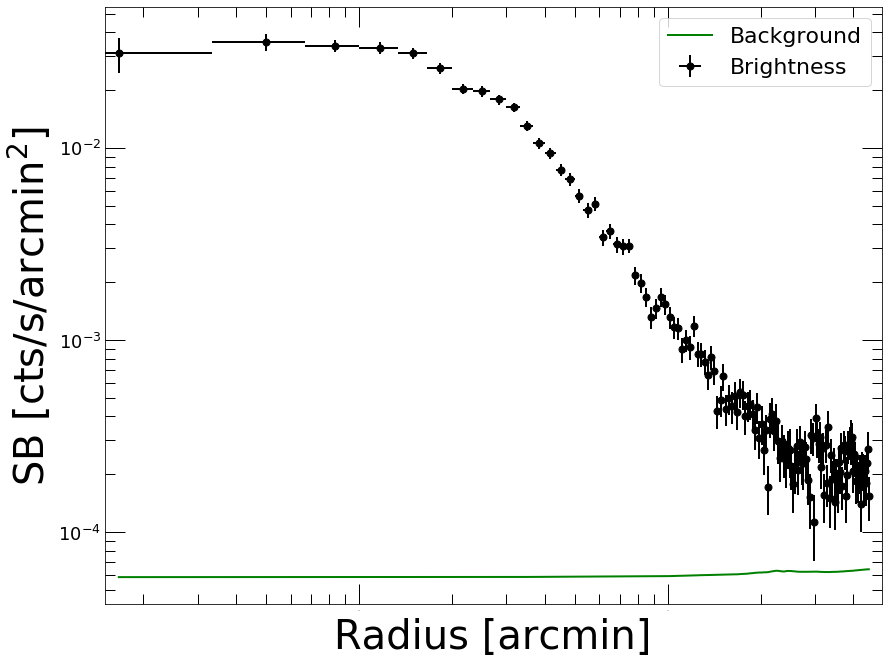

In [11]:
prof.Plot()

## Defining a model ##

Models can be defined using the [Model](https://pyproffit.readthedocs.io/en/latest/pyproffit.html#pyproffit.models.Model) class. PyProffit includes several popular built-in models, however the [Model](https://pyproffit.readthedocs.io/en/latest/pyproffit.html#pyproffit.models.Model) structure is designed to be compatible with any custom Python function (see below)

In [12]:
mod=pyproffit.Model(pyproffit.BetaModel)

To check the parameters of the [BetaModel](https://pyproffit.readthedocs.io/en/latest/pyproffit.html#pyproffit.models.BetaModel) function,

In [13]:
mod.parnames

('beta', 'rc', 'norm', 'bkg')

Any user-defined Python function operating on NumPy arrays can be defined here, see below.

## Fitting the data ##

To fit the extracted profiles PyProffit provides the [Fitter](https://pyproffit.readthedocs.io/en/latest/pyproffit.html#pyproffit.fitting.Fitter) class, which takes a [Profile](https://pyproffit.readthedocs.io/en/latest/pyproffit.html#pyproffit.profextract.Profile) and a [Model](https://pyproffit.readthedocs.io/en/latest/pyproffit.html#pyproffit.models.Model) object as input:

In [14]:
fitobj=pyproffit.Fitter(model=mod, profile=prof, beta=0.7, rc=2.,norm=-2,bkg=-4)

fitobj.Migrad()


┌──────────────────────────────────┬──────────────────────────────────────┐
,│ FCN = 143.5                      │              Nfcn = 273              │
,│ EDM = 1.13e-05 (Goal: 0.0002)    │                                      │
,├───────────────┬──────────────────┼──────────────────────────────────────┤
,│ Valid Minimum │ Valid Parameters │        No Parameters at limit        │
,├───────────────┴──────────────────┼──────────────────────────────────────┤
,│ Below EDM threshold (goal x 10)  │           Below call limit           │
,├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
,│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
,└───────────────┴──────────────────┴───────────┴─────────────┴────────────┘
,┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
,│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
,├───┼──────┼───────────┼───────────┼──────────

The fit provides the best-fit parameters with their errors and the covariance matrix. The fit statistic is provided at the bottom. All the results of the optimization can be accessed through the _fitobj.out_ attribute of the Fitter class, which contains the output of the iminuit _migrad_ command.

Now we can plot the data together with the best fitting model

<Figure size 432x288 with 0 Axes>

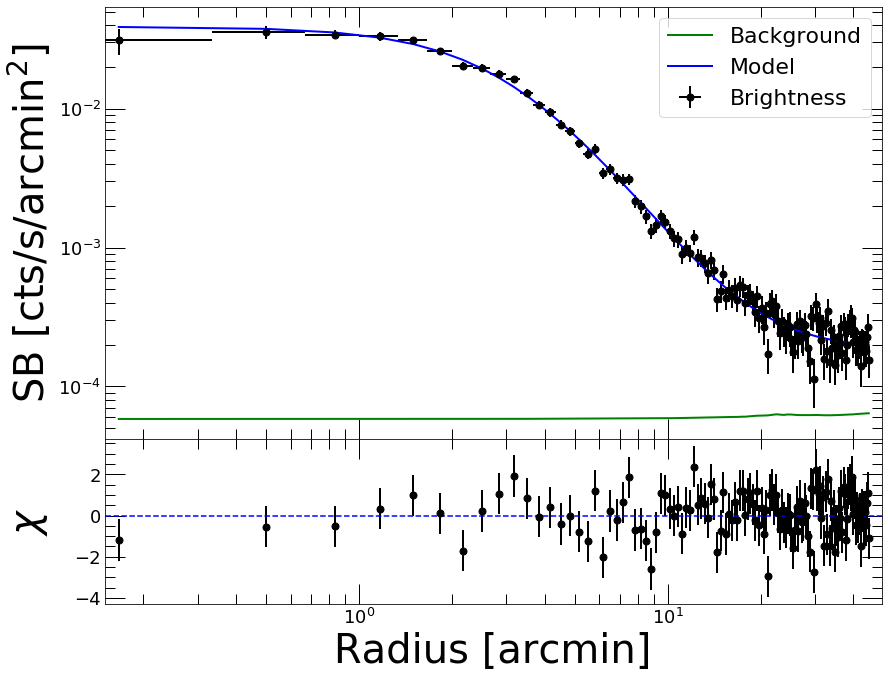

In [15]:
prof.Plot(model=mod)